In [1]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="keras.src.export.tf2onnx_lib"
)
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Conv2D, LSTM, Input, MaxPooling2D, Reshape, Bidirectional, StringLookup
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.constants import *
from src.helpers import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.backend import ctc_batch_cost, int_shape, ctc_decode
import editdistance

### File paths and labels

In [2]:
df = pd.read_csv(TRAIN_TSV, sep='\t', header=None, names=['file', 'label'])
df = df.dropna(subset=['label']).reset_index(drop=True) # 2 entries with no label
image_paths = [TRAIN_DIR + "/" + f for f in df["file"].values]
labels = df["label"].values

df

,file,label
0,aa1.png,Молдова
1,aa1007.png,продолжила борьбу
2,aa101.png,разработанные
3,aa1012.png,Плачи
4,aa1013.png,Гимны богам
...,...,...
72279,yob20539.png,Ответственность в/сл-
72280,yob20543.png,независимо
72281,yob20544.png,от воинского звания
72282,yob20545.png,воинской


### Alphabet of possible values

In [3]:
import unicodedata
chars = list(set(char for label in labels for char in label))

for char in chars:
    script = unicodedata.name(char, 'idk')
    print(f"{char}: {script}")

max([len(label) for label in labels]) # the kaggle page said 40, this is just to confirm it
#len(chars) 107

,: COMMA
ъ: CYRILLIC SMALL LETTER HARD SIGN
R: LATIN CAPITAL LETTER R
Е: CYRILLIC CAPITAL LETTER IE
]: RIGHT SQUARE BRACKET
С: CYRILLIC CAPITAL LETTER ES
№: NUMERO SIGN
п: CYRILLIC SMALL LETTER PE
(: LEFT PARENTHESIS
ж: CYRILLIC SMALL LETTER ZHE
s: LATIN SMALL LETTER S
o: LATIN SMALL LETTER O
э: CYRILLIC SMALL LETTER E
З: CYRILLIC CAPITAL LETTER ZE
): RIGHT PARENTHESIS
и: CYRILLIC SMALL LETTER I
К: CYRILLIC CAPITAL LETTER KA
Х: CYRILLIC CAPITAL LETTER HA
!: EXCLAMATION MARK
Э: CYRILLIC CAPITAL LETTER E
И: CYRILLIC CAPITAL LETTER I
А: CYRILLIC CAPITAL LETTER A
Н: CYRILLIC CAPITAL LETTER EN
Т: CYRILLIC CAPITAL LETTER TE
h: LATIN SMALL LETTER H
Щ: CYRILLIC CAPITAL LETTER SHCHA
Л: CYRILLIC CAPITAL LETTER EL
x: LATIN SMALL LETTER X
О: CYRILLIC CAPITAL LETTER O
ф: CYRILLIC SMALL LETTER EF
ы: CYRILLIC SMALL LETTER YERU
e: LATIN SMALL LETTER E
+: PLUS SIGN
д: CYRILLIC SMALL LETTER DE
»: RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK
4: DIGIT FOUR
Ч: CYRILLIC CAPITAL LETTER CHE
p: LATIN SMALL LETTE

40

In [4]:
label_to_int = StringLookup(vocabulary=chars, num_oov_indices=0) # encode
label_to_str = StringLookup(vocabulary=label_to_int.get_vocabulary(), invert=True) # decode

I0000 00:00:1769093342.075170  209956 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6053 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


### Dataset

In [5]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor= 2/180.0,
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomZoom(
        height_factor= 0.0,
        width_factor= (-0.05, 0.05),
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomContrast(0.15),
])

In [6]:
def build_dataset(paths, labels, batch_size, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(1024)

    def load_and_process(p, y):
        img = load_img(p)
        y = label_to_int(tf.strings.unicode_split(y, input_encoding="UTF-8"))
        y = tf.cast(y, tf.int32) + 1
        if training:
            img = augmentation(img, training=True)
        return {"img_input": img, "label_input": y}, y

    ds = ds.map(load_and_process, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.padded_batch(batch_size, padded_shapes=({"img_input": [IM_HEIGHT, IM_WIDTH, 1], "label_input": [None]}, [None]),
        padding_values=({"img_input": 0.0, "label_input": 0}, 0)
    )
    
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [7]:
def decode_output(y_pred) -> list[str]:
    input_len = np.ones(y_pred.shape[0]) * y_pred.shape[1]
    decoded, _ = tf.keras.backend.ctc_decode(y_pred, input_len, greedy=True)

    res = []
    for seq in decoded[0].numpy():
        seq = seq[seq != -1]
        text = b"".join(label_to_str(seq).numpy()).decode("utf-8")
        res.append(text)
    return res

### 80/20 train dataset split

In [8]:
# TODO: REMOVE CUTOFF LATER
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths[:1500], labels[:1500], test_size=VALIDATION_SIZE, random_state=67)

train_ds = build_dataset(train_paths, train_labels, batch_size=32, training=True)
val_ds = build_dataset(val_paths, val_labels, batch_size=32, training=False)

### Model

In [9]:
class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_func = ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_size = tf.cast(tf.shape(y_true)[0], tf.int32)
        input_len = tf.cast(tf.shape(y_pred)[1], tf.int32)
        input_len *= tf.ones((batch_size, 1), tf.int32)

        label_len = tf.math.count_nonzero(y_true, axis=1, keepdims=True)
        
        loss = self.loss_func(y_true, y_pred, input_len, label_len)
        self.add_loss(loss)
        return y_pred

In [10]:
img_input = Input(shape=(IM_HEIGHT, IM_WIDTH, 1), name="img_input")
label_input = Input(shape=(None,), dtype=tf.int32, name="label_input")

# stride for a more general overview of the image, more precise conv later
x = Conv2D(64, 5, strides=2, padding="same", activation=tf.nn.leaky_relu, name="conv1")(img_input)
x = MaxPooling2D(name="pool1")(x)

x = Conv2D(64, 3, padding="same", activation=tf.nn.leaky_relu, name="conv2")(x)
x = MaxPooling2D(name="pool2")(x)

shape = int_shape(x)
h, w, c = shape[1], shape[2], shape[3]
x = Reshape(target_shape=(w, h * c), name="shape1")(x)
x = Dense(192, activation=tf.nn.leaky_relu, name="dense1")(x)

x = Bidirectional(LSTM(256, return_sequences=True), name="lstm1")(x)
x = Bidirectional(LSTM(128, return_sequences=True), name="lstm2")(x)

x = Dense(len(chars)+2, activation="softmax", name="softmax")(x) # +1 for the blank char and +1 for padding

output = CTCLayer(name="ctc")(label_input, x)

model = Model(inputs=[img_input, label_input], outputs=output)
model.compile(optimizer="adam")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 200, 800,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 100, 400,  │      1,664 │ img_input[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 50, 200,   │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 50, 200,   │     36,928 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 25, 100,   │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shape1 (Reshape)    │ (None, 100, 1600) │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 100, 192)  │    307,392 │ shape1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1               │ (None, 100, 512)  │    919,552 │ dense1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2               │ (None, 100, 256)  │    656,384 │ lstm1[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 100, 109)  │     28,013 │ lstm2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc (CTCLayer)      │ (None, 100, 109)  │          0 │ label_input[0][0… │
│                     │                   │            │ softmax[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,949,933 (7.44 MB)

 Trainable params: 1,949,933 (7.44 MB)

 Non-trainable params: 0 (0.00 B)

### Metrics

###  Performance: character error rate, exact word match
### Training: learning rate, length ratio, blank ratio

In [11]:
class CustomCallbacks(tf.keras.callbacks.Callback):
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs):
        # predicting and getting the true labels
        truths = []
        preds = []
        preds_probs = []
        for imgs, labels in self.val_ds:
            pred = self.model(imgs, training=False)
            preds_probs.append(pred)
            preds.extend(decode_output(pred))
            for seq in labels.numpy():
                seq = seq[seq != 0]
                truths.append(b"".join(label_to_str(seq).numpy()).decode("utf-8"))

        # Character error rate (average levenshtein distance, the lower the better)
        total_edits = 0
        total_chars = 0
        for p, t in zip(preds, truths):
            total_edits += editdistance.eval(p, t)
            total_chars += len(t)
        cer = total_edits / max(1, total_chars)
        
        # Exact word match (the higher the better)
        correct = sum(p == t for p, t in zip(preds, truths))
        ewm = correct / max(1, len(truths))

        # Blank ratio (how many characters are being predicted as blanks)
        # (generally the lower the better)
        logits = tf.concat(preds_probs, axis=0)
        pred_ids = tf.argmax(logits, axis=-1)
        blank_idx = logits.shape[-1] - 1
        blanks = tf.equal(pred_ids, blank_idx)
        blank_cnt = tf.reduce_sum(tf.cast(blanks, tf.float32))
        total_steps = tf.cast(tf.size(pred_ids), tf.float32)
        blank_ratio = (blank_cnt / tf.maximum(1., total_steps)).numpy()
        
        # Length ratio (how long the predicted label is vs. the actual length)
        # (1.0 is the ideal value)
        pred_lengths = [len(p) for p in preds]
        truth_lengths = [len(t) for t in truths]
        len_ratio = sum(pred_lengths) / max(1, sum(truth_lengths))

        logs['val_cer'] = cer
        logs['val_ewm'] = ewm
        logs['val_blank_ratio'] = blank_ratio
        logs['val_len_ratio'] = len_ratio
        print()
        print(truths[:5])
        print(preds[:5])

### Overfitting experiment

In [12]:
overfit_ds = build_dataset(train_paths[:5], train_labels[:5], 5, False)
# for input, _ in overfit_ds.take(1):
    # print(input['img_input'].shape)
    # print(input['label_input'].shape)
    # print(label_to_str(input['label_input']))
callbacks = CustomCallbacks(overfit_ds)
model.fit(overfit_ds, validation_data=overfit_ds, epochs=1000, callbacks=[callbacks])


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 2198.0735
['причине', 'снова', 'т.к.', 'ство', 'что']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 2198.0735 - val_loss: 1934.5637 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000 - val_len_ratio: 0.0000e+00
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1934.5637
['причине', 'снова', 'т.к.', 'ство', 'что']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - loss: 1934.5637 - val_loss: 1024.3069 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000 - val_len_ratio: 0.0000e+00
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 1024.3069
['причине', 'снова', 'т.к.', 'ство', 'что']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 1024.3069 - val_loss: 182.6802 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000 - val_len_ratio: 0.0000e+00
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 182.6802
['причине', 'снов

KeyboardInterrupt: 

In [ ]:
y_pred = model.predict(overfit_ds)

print(decode_output(y_pred))
print(list(train_labels[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
['приине', 'снова', 'т.к.', 'ство', 'что']
['причине', 'снова', 'т.к.', 'ство', 'что']


Real label: причине


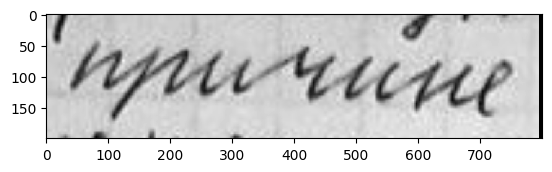

In [ ]:
for input, _ in overfit_ds.take(1):
    plt.imshow(input['img_input'][0, :, :, 0], cmap="gray", interpolation="nearest")
    print(f"Real label: {train_labels[0]}")

# Actual training

In [ ]:
early = EarlyStopping(monitor="val_cer", patience=20, restore_best_weights=True)
reduce = ReduceLROnPlateau(monitor="val_cer", mode='min', factor=0.2, patience=5, min_lr=10e-6)
board = TensorBoard(log_dir=LOG_DIR)
callbacks = CustomCallbacks(val_ds) # learning rate logged by default with the reduce callback

model.fit(train_ds, validation_data=val_ds, epochs=500, callbacks=[callbacks, reduce, board])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - grad_norm: 18.9978 - loss: 45.9845tf.Tensor(
[[108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108]], shape=(1, 100), dtype=int64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - grad_norm: 18.9978 - loss: 45.9845 - val_loss: 33.6602 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - grad_norm: 18.9653 - loss: 45.9489tf.Tensor(
[[108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 

KeyboardInterrupt: 

In [ ]:
y_pred = model.predict(overfit_ds)

print(decode_output(y_pred))
print(list(train_labels[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
['', '', '', '']
['Гимны богам', 'разработанные', 'продолжила борьбу', 'Плачи']
